# MERSCOPE Analysis

In [72]:
# Import necessary libraries
import scanpy as sc
import anndata as ad
import pandas as pd
import geopandas as gpd # For .parquet file with geometries
import matplotlib.pyplot as plt
import matplotlib.image as mpimg # For displaying images
import seaborn as sns
import numpy as np # For calculations if needed
import os
import squidpy
import warnings
import scipy.sparse

# Suppress FutureWarning messages
warnings.filterwarnings('ignore', category=FutureWarning)

In [73]:
os.chdir("/beegfs/scratch/ric.sessa/kubacki.michal/SRF_Linda_top/SRF_Spatial_segmentation")

# Define file paths
base_path = 'DATA/p30-E165/R4'
base_path_integrated = 'DATA_INTEGRATION'
h5ad_file = os.path.join(base_path_integrated, 'p30_R4_tangram_integrated_v3.h5ad')
original_h5ad_file = os.path.join(base_path, 'data.h5ad')

## 1. Data Loading

In [74]:
adata_integrated = None
try:
    adata_integrated = sc.read_h5ad(h5ad_file)
    print(f"Successfully loaded Integrated AnnData file: {h5ad_file}")
    print(adata_integrated)
except FileNotFoundError:
    print(f"Integrated AnnData file not found: {h5ad_file}.")
except Exception as e:
    print(f"Error loading Integrated AnnData file {h5ad_file}: {e}.")

Successfully loaded Integrated AnnData file: DATA_INTEGRATION/p30_R4_tangram_integrated_v3.h5ad
AnnData object with n_obs × n_vars = 22613 × 22606
    obs: 'volume', 'center_x', 'center_y', 'n_counts', 'n_genes', 'leiden', 'uniform_density', 'rna_count_based_density'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std', 'is_training'
    uns: 'condition_colors', 'genotype_colors', 'hvg', 'leiden_0.4', 'leiden_0.4_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'


In [75]:
adata_original = None
try:
    adata_original = sc.read_h5ad(original_h5ad_file)
    print(f"Successfully loaded Raw Spatial AnnData file: {original_h5ad_file}")
    print(adata_original)
except FileNotFoundError:
    print(f"Raw spatial AnnData file not found: {original_h5ad_file}.")
except Exception as e:
    print(f"Error loading raw spatial AnnData file {original_h5ad_file}: {e}.")

Successfully loaded Raw Spatial AnnData file: DATA/p30-E165/R4/data.h5ad
AnnData object with n_obs × n_vars = 22613 × 960
    obs: 'volume', 'center_x', 'center_y', 'n_counts', 'n_genes', 'leiden'
    var: 'mean', 'std'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [76]:
print(adata_integrated.obs.index[:5])
print(adata_integrated.obs.volume.head())
print(adata_integrated.obs.center_x.head())
print(adata_integrated.obs.leiden.head())

Index(['1678497000000100030', '1678497000000100031', '1678497000000100032',
       '1678497000000100033', '1678497000000100035'],
      dtype='object', name='cell')
cell
1678497000000100030    2551.229934
1678497000000100031    1164.514849
1678497000000100032    1604.968082
1678497000000100033    2182.728229
1678497000000100035    1042.151256
Name: volume, dtype: float64
cell
1678497000000100030     9870.501629
1678497000000100031    10003.782457
1678497000000100032    10055.359602
1678497000000100033    10122.192315
1678497000000100035     9955.601503
Name: center_x, dtype: float64
cell
1678497000000100030    1
1678497000000100031    1
1678497000000100032    1
1678497000000100033    7
1678497000000100035    6
Name: leiden, dtype: category
Categories (25, object): ['0', '1', '2', '3', ..., '21', '22', '23', '24']


In [77]:
print(f"adata_integrated.X data type: {adata_integrated.X.dtype}")
if scipy.sparse.issparse(adata_integrated.X):
    print(adata_integrated.X[:5, :5].toarray())
    if adata_integrated.X.nnz > 0: # nnz is number of stored_elements
        print(f"Min non-zero value in adata_integrated.X: {adata_integrated.X.data.min()}")
        print(f"Max non-zero value in adata_integrated.X: {adata_integrated.X.data.max()}")
else: # Dense array
    print(adata_integrated.X[:5, :5])
    print(f"Min value in adata_integrated.X: {adata_integrated.X.min()}")
    print(f"Max value in adata_integrated.X: {adata_integrated.X.max()}")

adata_integrated.X data type: float64
[[ 0.00022775 -0.00485708 -0.01580961 -0.00743909 -0.00872695]
 [-0.00012407  0.00637212  0.00382805  0.0159801  -0.00826255]
 [ 0.00058033  0.00023733  0.01067167 -0.00573304 -0.01065428]
 [-0.00308371 -0.00363547 -0.00711612 -0.0036199  -0.01076923]
 [-0.00329409  0.00013146  0.00204061 -0.00413794 -0.00534815]]
Min value in adata_integrated.X: -0.06587844638454526
Max value in adata_integrated.X: 0.48612036552060556


In [78]:
print(f"adata_original.X data type: {adata_original.X.dtype}")
if scipy.sparse.issparse(adata_original.X):
    print(adata_original.X[:5, :5].toarray())
    if adata_original.X.nnz > 0:
        print(f"Min non-zero value in adata_original.X: {adata_original.X.data.min()}")
        print(f"Max non-zero value in adata_original.X: {adata_original.X.data.max()}")
else: # Dense array
    print(adata_original.X[:5, :5])
    print(f"Min value in adata_original.X: {adata_original.X.min()}")
    print(f"Max value in adata_original.X: {adata_original.X.max()}")

adata_original.X data type: float32
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
Min value in adata_original.X: 0.0
Max value in adata_original.X: 50.36949920654297


# 2. Exploratory Data Analysis

In [79]:
print(f"Number of cells: {adata_integrated.n_obs}")
print(f"Number of genes: {adata_integrated.n_vars}")

Number of cells: 22613
Number of genes: 22606


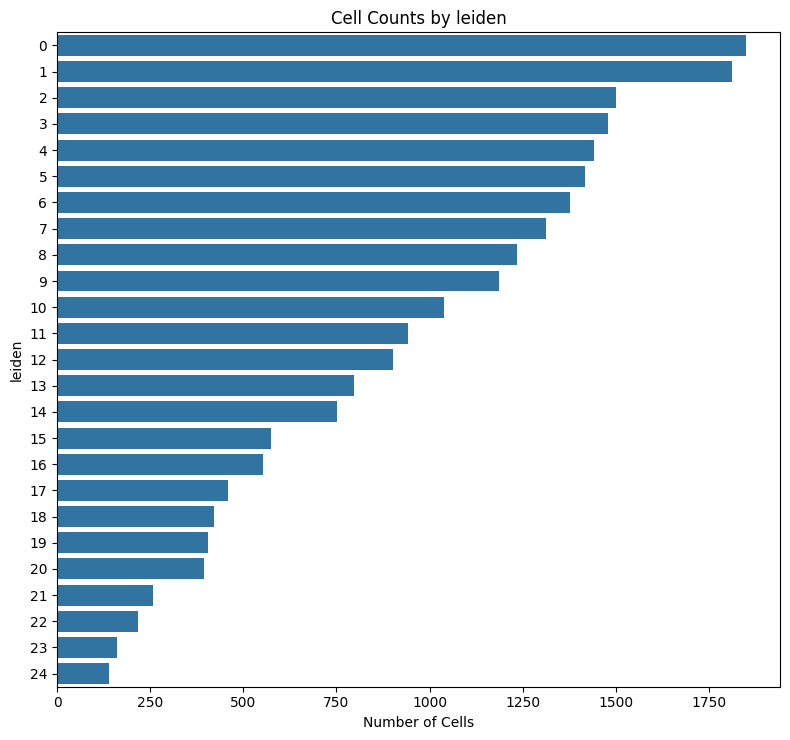

In [80]:
coll_to_summary = 'leiden'

if adata_integrated.obs[coll_to_summary].nunique() < 30 and adata_integrated.obs[coll_to_summary].nunique() > 1:
    plt.figure(figsize=(8, max(4, adata_integrated.obs[coll_to_summary].nunique() * 0.3)))
    sns.countplot(y=adata_integrated.obs[coll_to_summary], order = adata_integrated.obs[coll_to_summary].value_counts(dropna=False).index)
    plt.title(f"Cell Counts by {coll_to_summary}")
    plt.xlabel("Number of Cells")
    plt.ylabel(coll_to_summary)
    plt.tight_layout()
    plt.show()

## 3. Visualization

In [81]:
print(adata_integrated.obsm_keys())
print(list(adata_integrated.obs.columns))

[]
['volume', 'center_x', 'center_y', 'n_counts', 'n_genes', 'leiden', 'uniform_density', 'rna_count_based_density']


In [82]:
adata_integrated.obsm['spatial'] = adata_integrated.obs[['center_x', 'center_y']].to_numpy()
spatial_coords_available = True
print(adata_integrated.obsm_keys())

['spatial']


<Figure size 1000x1000 with 0 Axes>

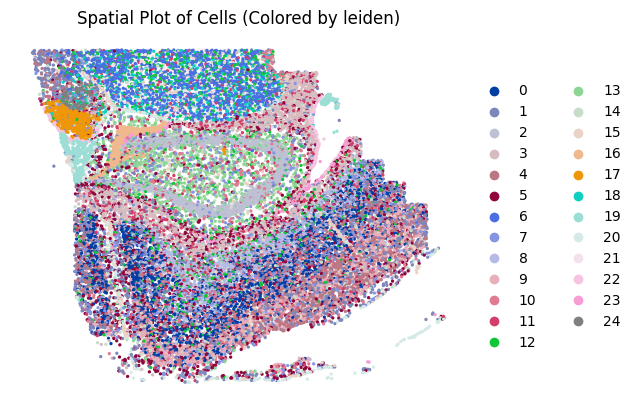

<Figure size 1000x1000 with 0 Axes>

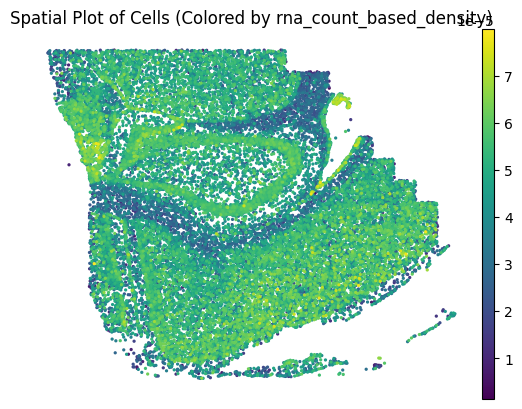

In [83]:
features = ['leiden', 'rna_count_based_density']
for color_by in features:
    plt.figure(figsize=(10, 10))
    sc.pl.spatial(adata_integrated, color=color_by, spot_size=30, show=False, frameon=False)
    plt.title(f"Spatial Plot of Cells (Colored by {color_by if color_by else 'default'})")
    plt.show()

In [84]:
print(list(adata_integrated.var.columns))
print(list(adata_integrated.uns))

['gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std', 'is_training']
['condition_colors', 'genotype_colors', 'hvg', 'leiden_0.4', 'leiden_0.4_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap', 'leiden_colors']


In [85]:
adata_integrated.var['highly_variable'].head()

xkr4       False
gm1992     False
gm19938    False
gm37381    False
rp1         True
Name: highly_variable, dtype: bool

Plotting spatial expression for HVGs: ['rp1', 'sox17', 'rgs20']


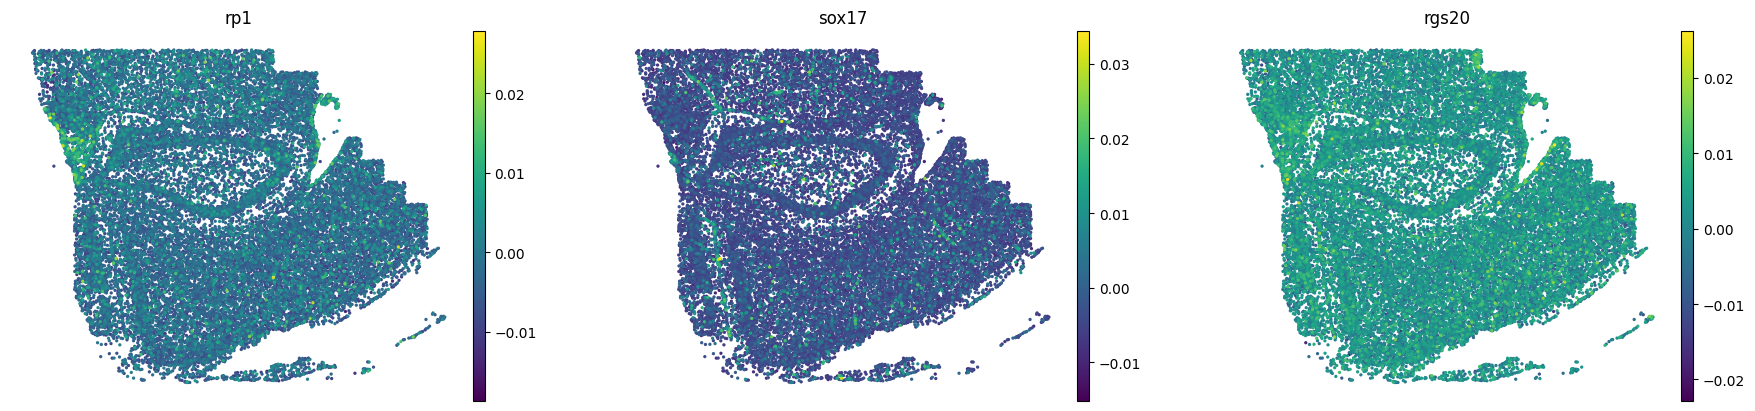

In [86]:
hvg_genes = adata_integrated.var_names[adata_integrated.var['highly_variable']].tolist()
if len(hvg_genes) > 0:
    num_genes_to_plot = min(len(hvg_genes), 3)
    genes_to_plot = hvg_genes[:num_genes_to_plot]
    print(f"Plotting spatial expression for HVGs: {genes_to_plot}")
    sc.pl.spatial(adata_integrated, color=genes_to_plot, spot_size=30, show=True, frameon=False, ncols=num_genes_to_plot)
else:
    print("No highly variable genes found after computation.")

In [87]:
sc.tl.pca(adata_integrated)

In [88]:
sc.pp.neighbors(adata_integrated)
sc.tl.umap(adata_integrated)

/beegfs/scratch/ric.sessa/kubacki.michal/conda/envs/vpt/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


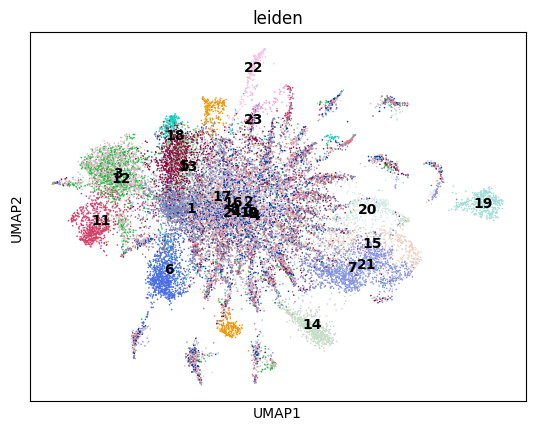

In [89]:
sc.pl.umap(adata_integrated, color="leiden", legend_loc='on data')

## 4. Plotting specific genes

In [90]:
adata_integrated.var_names[:20]

Index(['xkr4', 'gm1992', 'gm19938', 'gm37381', 'rp1', 'sox17', 'mrpl15',
       'a930006a01rik', 'lypla1', 'tcea1', 'rgs20', 'gm16041', 'atp6v1h',
       'oprk1', 'npbwr1', '4732440d04rik', 'rb1cc1', 'alkal1', 'st18',
       'gm57122'],
      dtype='object')

Plotting spatial expression for custom genes: ['ppfia2', 'rfx3', 'dgkh', 'glis3']


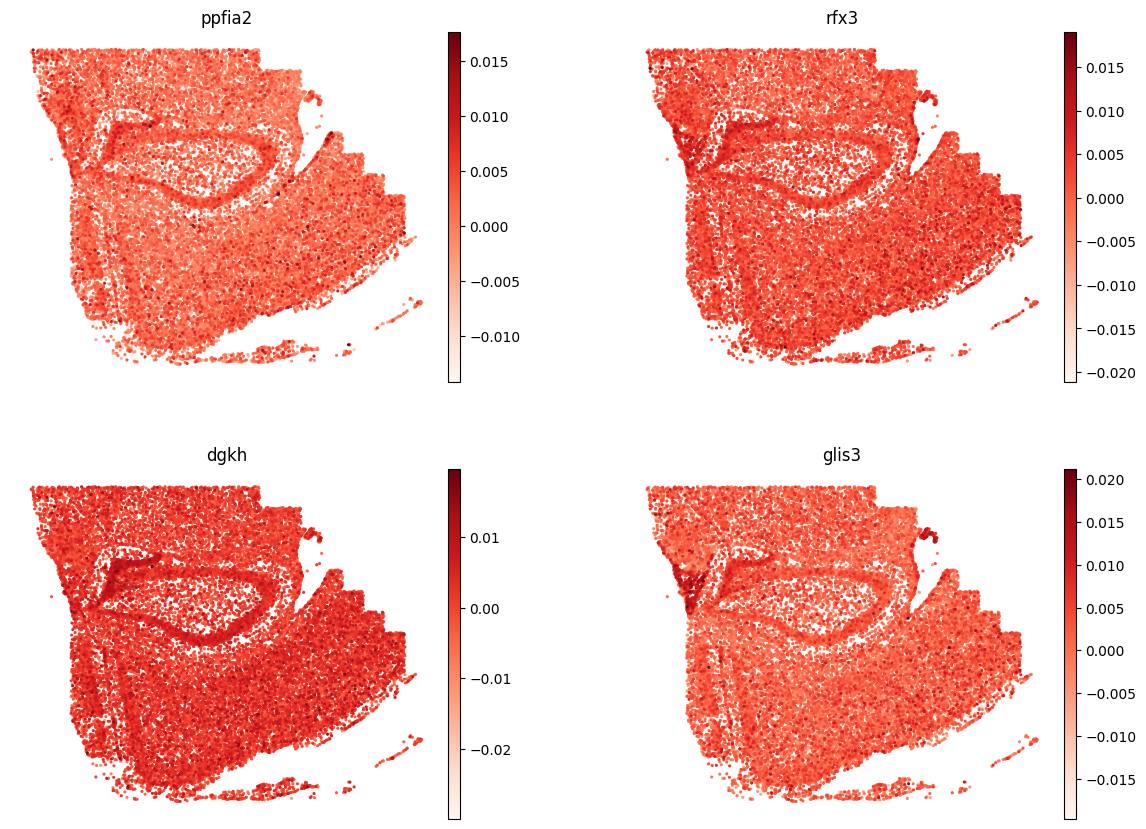

In [91]:
# Top DEGs from Cluster_Mature GC_vs_Rest_up_significant.csv
genes_to_plot_custom = ['ppfia2', 'rfx3', 'dgkh', 'glis3']
existing_genes = [gene for gene in genes_to_plot_custom if gene in adata_integrated.var_names]

if len(existing_genes) > 0:
    print(f"Plotting spatial expression for custom genes: {existing_genes}")
    sc.pl.spatial(adata_integrated, color=existing_genes, spot_size=30, show=True, frameon=False, ncols=2, cmap='Reds')
else:
    print(f"None of the specified genes were found in the AnnData object: {genes_to_plot_custom}")

Plotting spatial expression for custom genes: ['cpne7', 'epha6', 'hs6st3', 'gm10754']


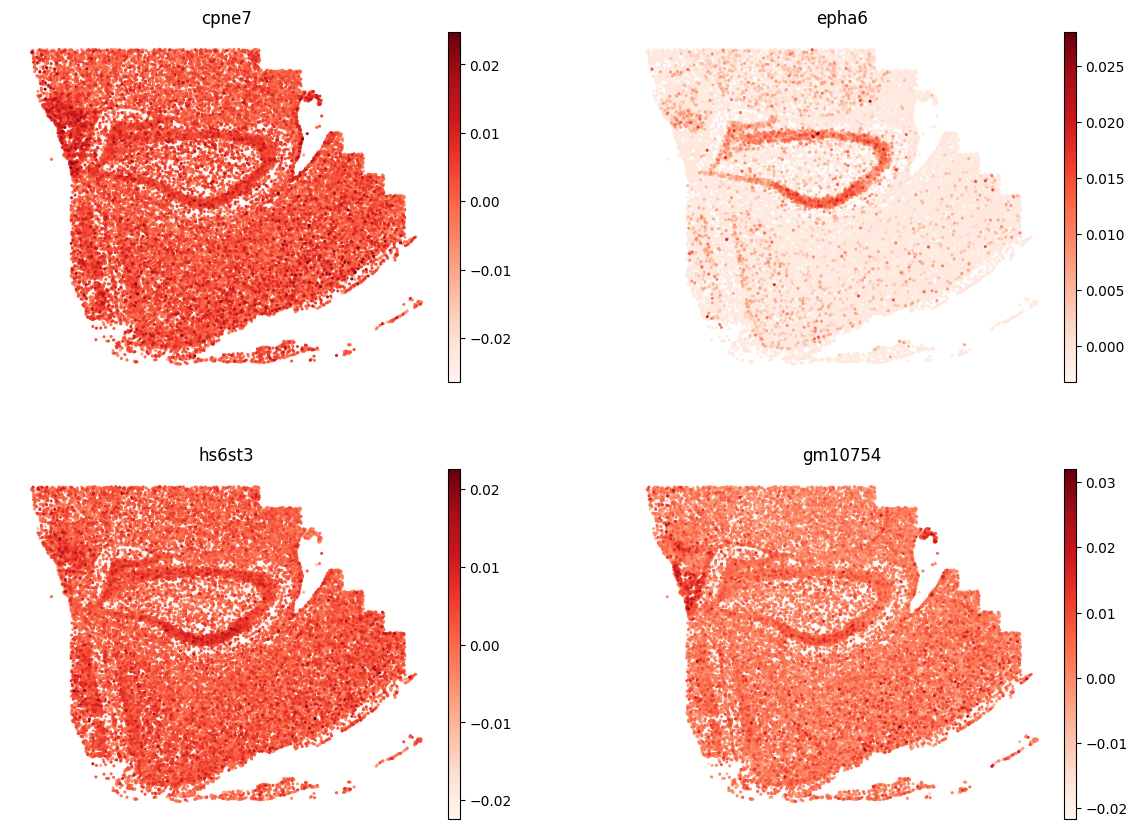

In [92]:
# Top DEGs from Cluster_Mature Cluster_CTX Cluster_CTX_vs_Rest_up_significant.csv
genes_to_plot_custom = ["cpne7", "epha6", "hs6st3", "gm10754"]
existing_genes = [gene for gene in genes_to_plot_custom if gene in adata_integrated.var_names]

if len(existing_genes) > 0:
    print(f"Plotting spatial expression for custom genes: {existing_genes}")
    sc.pl.spatial(adata_integrated, color=existing_genes, spot_size=30, show=True, frameon=False, ncols=2, cmap='Reds')
else:
    print(f"None of the specified genes were found in the AnnData object: {genes_to_plot_custom}")